# Planning and Learning with Tabular Methods

Following **Chapter 8** from *Reinforcement Learning* (edition 2) by Andrew Barto and Richard S. Sutton

### Setup

In [1]:
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from typing import Callable, Any, Optional
from IPython.display import HTML

from util.envs import GridMazeEnv, Action, State

In [2]:
def initialize_Q_pi(
    env_num_rows: int, 
    env_num_cols: int, 
    env_goal: tuple[int, int], 
    actions: tuple[Action, ...]
    ) -> dict:
    
    Q = {}
    for row in range(env_num_rows):
        for col in range(env_num_cols):
            s = (row, col)
            if s == env_goal:
                Q[s] = np.zeros(len(actions)) # zeros Q(terminal, all_a)
                continue
            Q[s] = -np.random.random(len(actions)) # arbitrary Q(s, a)
    return Q

def initialize_model(
    env_num_rows: int, 
    env_num_cols: int, 
    env_goal: tuple[int, int], 
    actions: tuple[Action, ...]
    ) -> dict[tuple[State, Action], Optional[tuple[float, State]]]:
    """
    Returns:
        dict[tuple[State, Action], Optional[tuple[State, float]]]: keys are (s, a) pairs; values are (r, s') or None
    """
    
    model = {}
    for row in range(env_num_rows):
        for col in range(env_num_cols):
            s = (row, col)
            if s == env_goal:
                continue
            for a in actions:
                model_key = (s, a)
                model[model_key] = None
    return model


def pi_epsilon_greedy(s: tuple[int, int], Q_pi: dict | tuple[dict, dict], epsilon: float) -> int:
    p = np.random.random()
    
    if isinstance(Q_pi, dict): # Regular
        Q_pi_s = Q_pi[s]
    elif isinstance(Q_pi, tuple): # Double learning
        Q_pi_s = Q_pi[0][s] + Q_pi[1][s] # action via addition from the 2 value functions

    if p < epsilon: # explore
        return int(np.random.randint(len(Q_pi_s)))
    return int(np.argmax(Q_pi_s)) # exploit

### Dyna-Q

Page *161*, chapter *8.2*

In [3]:
maze_grid = np.array([
    [0, 0, 0, 0, 0, 0, 0, 1, 3],
    [0, 0, 1, 0, 0, 0, 0, 1, 0],
    [2, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0],
])

maze_env = GridMazeEnv(maze_grid)
maze_env

[[□ □ □ □ □ □ □ ■ G]
 [□ □ ■ □ □ □ □ ■ □]
 [S □ ■ □ □ □ □ ■ □]
 [□ □ ■ □ □ □ □ □ □]
 [□ □ □ □ □ □ □ □ □]
 [□ □ □ □ □ ■ □ □ □]]

In [13]:
gamma = 0.9 # discounting
alpha = 0.1 # step size
n = 10 # planning steps
num_epochs = 50

Q_pi: dict = initialize_Q_pi(maze_env.num_rows, maze_env.num_cols, maze_env.goal_position, maze_env.action_set)
model: dict = initialize_model(maze_env.num_rows, maze_env.num_cols, maze_env.goal_position, maze_env.action_set)

episode_lengths = []

observed_sa = []
for epoch in tqdm(range(num_epochs)):
    step = 0
    epsilon = max(0.1, 1 / (epoch + 1)) # decaying epsilon

    s = maze_env.reset()
    while True:
        # --- direct rl ---
        a_idx = pi_epsilon_greedy(s, Q_pi, epsilon)
        a = maze_env.action_set[a_idx]

        r, s_prime, done = maze_env.step(a)

        target = r + gamma * max(Q_pi[s_prime]) # Q-learning target
        error =  target - Q_pi[s][a_idx] # Q-learning error
        Q_pi[s][a_idx] += alpha * error # Update
        
        model[(s, a)] = (r, s_prime) # Update model - assumes deterministic world

        s = s_prime
        step += 1
        if done:
            break

        # --- planning ---
        model_visited_sa = [k for k, v in model.items() if v is not None]
        for i in range(n):
            s_sampled, a_sampled = random.choice(model_visited_sa) # Sample previously visited s and chosen a
            a_sampled_idx = maze_env.action_set.index(a_sampled)
            r_modelled, s_prime_modelled = model[(s_sampled, a_sampled)] # Use model to 'predict' what r and s' would be

            planning_target = r_modelled + gamma * max(Q_pi[s_prime_modelled]) # Q-learning target (planning)
            planning_error = planning_target - Q_pi[s_sampled][a_sampled_idx] # Q-learning error (planning)
            Q_pi[s_sampled][a_sampled_idx] += alpha * planning_error # Update (planning)

    episode_lengths.append(step)

100%|██████████| 50/50 [00:00<00:00, 612.23it/s]


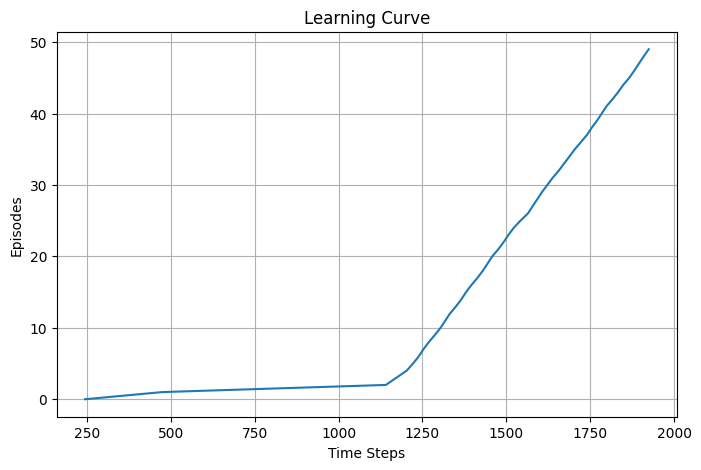

In [14]:
maze_env.plot_time_steps_per_episode(episode_lengths)

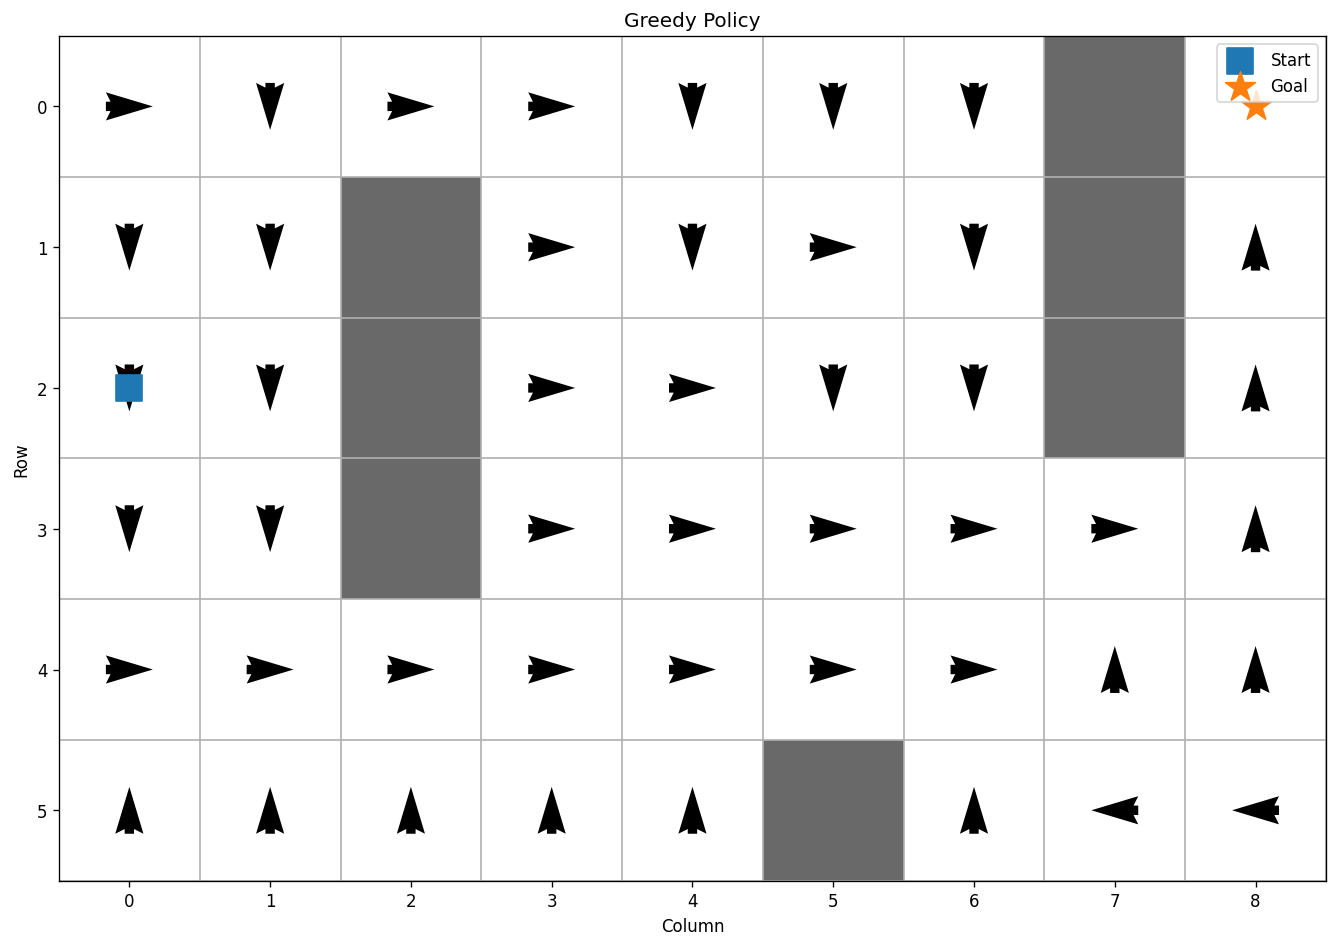

In [15]:
maze_env.plot_policy(Q_pi, maze_env.action_set)

In [17]:
_ = maze_env.animate_episode_with_trail(Q_pi, maze_env.action_set)

In [ ]:
# TO-DO: Plot learning curves for Dyna-Q with varying n-values for planning